In [ ]:
import os
import cv2
import random
import numpy as np
import datetime as dt
import tensorflow as tf
import matplotlib.pyplot as plt
from collections import deque
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import *
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

seed_constant = 42
np.random.seed(seed_constant)
random.seed(seed_constant)
tf.random.set_seed(seed_constant)

print("Imports loaded successfully!")
print("TensorFlow version:", tf.__version__)

Imports loaded successfully!
TensorFlow version: 2.19.0


In [16]:
import zipfile
import os
if os.path.exists("UCF11.zip"):
    with zipfile.ZipFile("UCF11.zip", 'r') as zip_ref:
        zip_ref.extractall(".")

    print("Extraction complete!")

    print("\nExtracted contents:")
    for item in os.listdir("."):
        if os.path.isdir(item):
            print(f"  - {item}")

else:
    print("UCF11.zip not found!")

Extraction complete!

Extracted contents:
  - .config
  - soccer_juggling
  - walking
  - golf_swing
  - diving
  - volleyball_spiking
  - tennis_swing
  - trampoline_jumping
  - basketball
  - biking
  - .ipynb_checkpoints
  - swing
  - horse_riding
  - sample_data


In [ ]:
import os

IMAGE_HEIGHT = 64
IMAGE_WIDTH = 64

MAX_FRAMES_PER_CLASS = 8000

CLASSES_LIST = ["basketball", "biking", "tennis_swing"]
NUM_CLASSES = len(CLASSES_LIST)

DATASET_PATH = "."

print(f"Dataset path: {DATASET_PATH}")
print(f"Chosen classes: {CLASSES_LIST}")
print(f"Number of classes: {NUM_CLASSES}")
print(f"Image size: {IMAGE_HEIGHT} x {IMAGE_WIDTH}")
print(f"Max frames per class: {MAX_FRAMES_PER_CLASS}")

Dataset path: .
Chosen classes: ['basketball', 'biking', 'tennis_swing']
Number of classes: 3
Image size: 64 x 64
Max frames per class: 8000

Verifying classes...
 basketball: 0 videos found
 biking: 0 videos found
 tennis_swing: 0 videos found


In [ ]:
import cv2
import numpy as np

def extract_frames(video_path):
    frames_list = []
    video_reader = cv2.VideoCapture(video_path)

    if not video_reader.isOpened():
        print(f"Warning: Could not open video {video_path}")
        return frames_list

    while True:
        success, frame = video_reader.read()

        if not success:
            break
        resized_frame = cv2.resize(frame, (IMAGE_HEIGHT, IMAGE_WIDTH))
        normalized_frame = resized_frame / 255.0

        frames_list.append(normalized_frame)

    video_reader.release()

    return frames_list

print("Frame extraction function created!")

Frame extraction function created!


In [ ]:
import os
import cv2
import random
import numpy as np

def find_all_videos(root_folder):
    video_extensions = ['.avi', '.mp4', '.mov', '.flv', '.mpeg', '.mpg', '.mkv', '.webm', '.wmv']
    video_files = []

    for dirpath, dirnames, filenames in os.walk(root_folder):
        for filename in filenames:
            ext = os.path.splitext(filename)[1].lower()
            if ext in video_extensions:
                full_path = os.path.join(dirpath, filename)
                video_files.append(full_path)

    return video_files

def extract_frames(video_path):
    frames_list = []

    video_reader = cv2.VideoCapture(video_path)

    if not video_reader.isOpened():
        return frames_list

    while True:
        success, frame = video_reader.read()

        if not success:
            break
        resized_frame = cv2.resize(frame, (IMAGE_HEIGHT, IMAGE_WIDTH))
        normalized_frame = resized_frame / 255.0

        frames_list.append(normalized_frame)

    video_reader.release()

    return frames_list

def create_dataset():
    features = []
    labels = []
    for class_index, class_name in enumerate(CLASSES_LIST):
        print(f"\nProcessing class: {class_name}")

        if not os.path.exists(class_name):
            print(f" Folder {class_name} not found!")
            continue

        # Find all videos
        video_files = find_all_videos(class_name)

        print(f"  Found {len(video_files)} videos")

        all_frames = []

        for i, video_file in enumerate(video_files):
            frames = extract_frames(video_file)
            all_frames.extend(frames)
            if (i + 1) % 20 == 0:
                print(f"    Processed {i+1}/{len(video_files)} videos...")

        print(f"  Total frames extracted: {len(all_frames)}")

        if len(all_frames) == 0:
            print(f"  ⚠️ No frames extracted for {class_name}!")
            continue
        if len(all_frames) > MAX_FRAMES_PER_CLASS:
            sampled_frames = random.sample(all_frames, MAX_FRAMES_PER_CLASS)
        else:
            sampled_frames = all_frames

        features.extend(sampled_frames)
        labels.extend([class_index] * len(sampled_frames))

        print(f"Added {len(sampled_frames)} frames for {class_name}")

    if len(features) == 0:
        print("\nNo frames extracted from any class!")
        return np.array([]), np.array([])

    features = np.array(features)
    labels = np.array(labels)

    print(f"\nDataset created!")
    print(f"  Total samples: {len(features)}")
    print(f"  Feature shape: {features.shape}")

    return features, labels
features, labels = create_dataset()

if len(features) > 0:
    print(f"\nDataset creation successful!")
else:
    print(f"\nDataset creation failed.")


Processing class: basketball
  Found 141 videos
    Processed 20/141 videos...
    Processed 40/141 videos...
    Processed 60/141 videos...
    Processed 80/141 videos...
    Processed 100/141 videos...
    Processed 120/141 videos...
    Processed 140/141 videos...
  Total frames extracted: 19230
Added 8000 frames for basketball

Processing class: biking
  Found 145 videos
    Processed 20/145 videos...
    Processed 40/145 videos...
    Processed 60/145 videos...
    Processed 80/145 videos...
    Processed 100/145 videos...
    Processed 120/145 videos...
    Processed 140/145 videos...
  Total frames extracted: 32863
Added 8000 frames for biking

Processing class: tennis_swing
  Found 167 videos
    Processed 20/167 videos...
    Processed 40/167 videos...
    Processed 60/167 videos...
    Processed 80/167 videos...
    Processed 100/167 videos...
    Processed 120/167 videos...
    Processed 140/167 videos...
    Processed 160/167 videos...
  Total frames extracted: 26574
Added

In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

one_hot_labels = to_categorical(labels, NUM_CLASSES)

X_train, X_test, y_train, y_test = train_test_split(
    features, one_hot_labels,
    test_size=0.2,
    shuffle=True,
    random_state=seed_constant
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 19200
Testing samples: 4800


In [ ]:
from tensorflow.keras.layers import *
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping

def create_model():
    model = Sequential()
    model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu', input_shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3)))
    model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(GlobalAveragePooling2D())
    model.add(Dense(128, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))
    model.add(Dense(NUM_CLASSES, activation='softmax'))
    return model

model = create_model()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 60, 60, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,195 (188.26 KB)

 Trainable params: 47,811 (186.76 KB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, mode='min', restore_best_weights=True)

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history = model.fit(
    x=X_train, y=y_train,
    epochs=50, batch_size=32, shuffle=True,
    validation_split=0.2, callbacks=[early_stop], verbose=1
)

Epoch 1/50
480/480 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.7252 - loss: 0.6550 - val_accuracy: 0.5677 - val_loss: 0.7283
Epoch 2/50
480/480 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9180 - loss: 0.2308 - val_accuracy: 0.7904 - val_loss: 0.6604
Epoch 3/50
480/480 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9462 - loss: 0.1554 - val_accuracy: 0.8036 - val_loss: 0.5109
Epoch 4/50
480/480 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9627 - loss: 0.1096 - val_accuracy: 0.7411 - val_loss: 0.7038
Epoch 5/50
480/480 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9688 - loss: 0.0930 - val_accuracy: 0.9427 - val_loss: 0.1558
Epoch 6/50
480/480 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9738 - loss: 0.0755 - val_accuracy: 0.9518 - val_loss: 0.1261
Epoch 7/50
480/480 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9779 - loss: 0.0624 - val_accuracy: 0.9706 - val_loss: 0.1015
Epoch 8/50
480/480 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9825 - loss: 0.0494 - val_acc

Test Loss: 0.0012804226716980338
Test Accuracy: 0.9995833039283752


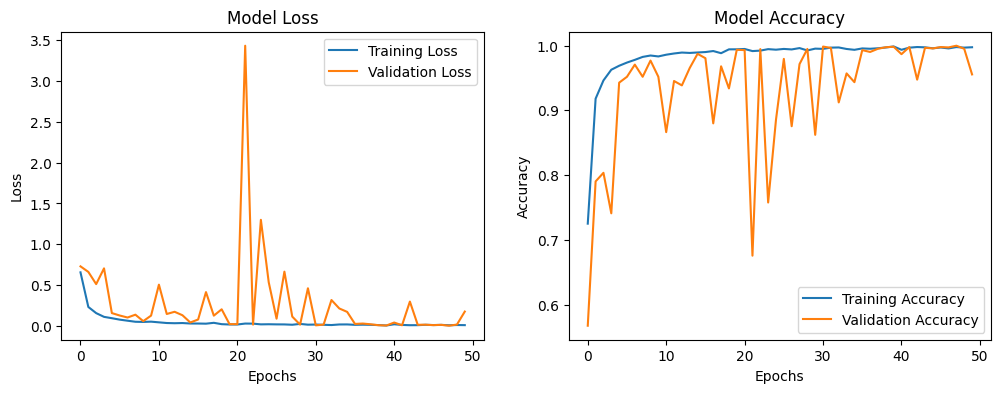

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('Model Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Training Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_title('Model Accuracy')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.show()

In [ ]:
student_name = "Layan"
save_path = f"{student_name}_ucf11_model.h5"
model.save(save_path)
print("Model saved as:", save_path)

from google.colab import files
files.download(save_path)

Model saved as: Layan_ucf11_model.h5


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
#for basketball
from google.colab import files
import cv2
import numpy as np

def predict_video(video_path):
    frames_list = []
    video_reader = cv2.VideoCapture(video_path)

    while True:
        success, frame = video_reader.read()
        if not success:
            break
        resized_frame = cv2.resize(frame, (IMAGE_HEIGHT, IMAGE_WIDTH))
        normalized_frame = resized_frame / 255.0
        frames_list.append(normalized_frame)

    video_reader.release()

    if len(frames_list) == 0:
        return None, 0

    num_frames = min(50, len(frames_list))
    sample_frames = random.sample(frames_list, num_frames)

    predictions = []
    for frame in sample_frames:
        pred = model.predict(np.expand_dims(frame, axis=0), verbose=0)[0]
        predictions.append(pred)

    avg_prediction = np.mean(predictions, axis=0)
    predicted_class_idx = np.argmax(avg_prediction)
    confidence = avg_prediction[predicted_class_idx]
    predicted_class = CLASSES_LIST[predicted_class_idx]

    return predicted_class, confidence, avg_prediction

print("Upload a video file to test:")
uploaded = files.upload()

for filename in uploaded.keys():
    print("Video:", filename)
    result = predict_video(filename)
    if result:
        pred_class, conf, probs = result
        print("Predicted:", pred_class)
        print("Confidence:", f"{conf:.2%}")
        print("All probabilities:")
        for i, class_name in enumerate(CLASSES_LIST):
            print(f"  {class_name}: {probs[i]:.2%}")

Upload a video file to test:


Saving Basketball jump shot - Slow motion video.mp4 to Basketball jump shot - Slow motion video.mp4
Video: Basketball jump shot - Slow motion video.mp4
Predicted: basketball
Confidence: 100.00%
All probabilities:
  basketball: 100.00%
  biking: 0.00%
  tennis_swing: 0.00%


In [ ]:
#for biking
from google.colab import files
import cv2
import numpy as np

def predict_video(video_path):
    frames_list = []
    video_reader = cv2.VideoCapture(video_path)

    while True:
        success, frame = video_reader.read()
        if not success:
            break
        resized_frame = cv2.resize(frame, (IMAGE_HEIGHT, IMAGE_WIDTH))
        normalized_frame = resized_frame / 255.0
        frames_list.append(normalized_frame)

    video_reader.release()

    if len(frames_list) == 0:
        return None, 0

    num_frames = min(50, len(frames_list))
    sample_frames = random.sample(frames_list, num_frames)

    predictions = []
    for frame in sample_frames:
        pred = model.predict(np.expand_dims(frame, axis=0), verbose=0)[0]
        predictions.append(pred)

    avg_prediction = np.mean(predictions, axis=0)
    predicted_class_idx = np.argmax(avg_prediction)
    confidence = avg_prediction[predicted_class_idx]
    predicted_class = CLASSES_LIST[predicted_class_idx]

    return predicted_class, confidence, avg_prediction

print("Upload a video file to test:")
uploaded = files.upload()

for filename in uploaded.keys():
    print("Video:", filename)
    result = predict_video(filename)
    if result:
        pred_class, conf, probs = result
        print("Predicted:", pred_class)
        print("Confidence:", f"{conf:.2%}")
        print("All probabilities:")
        for i, class_name in enumerate(CLASSES_LIST):
            print(f"  {class_name}: {probs[i]:.2%}")

Upload a video file to test:


Saving How to get on and off a bike (The right way...).mp4 to How to get on and off a bike (The right way...).mp4
Video: How to get on and off a bike (The right way...).mp4
Predicted: biking
Confidence: 94.76%
All probabilities:
  basketball: 2.02%
  biking: 94.76%
  tennis_swing: 3.22%


In [ ]:
#for tennis
from google.colab import files
import cv2
import numpy as np

def predict_video(video_path):
    frames_list = []
    video_reader = cv2.VideoCapture(video_path)

    while True:
        success, frame = video_reader.read()
        if not success:
            break
        resized_frame = cv2.resize(frame, (IMAGE_HEIGHT, IMAGE_WIDTH))
        normalized_frame = resized_frame / 255.0
        frames_list.append(normalized_frame)

    video_reader.release()

    if len(frames_list) == 0:
        return None, 0

    num_frames = min(50, len(frames_list))
    sample_frames = random.sample(frames_list, num_frames)

    predictions = []
    for frame in sample_frames:
        pred = model.predict(np.expand_dims(frame, axis=0), verbose=0)[0]
        predictions.append(pred)

    avg_prediction = np.mean(predictions, axis=0)
    predicted_class_idx = np.argmax(avg_prediction)
    confidence = avg_prediction[predicted_class_idx]
    predicted_class = CLASSES_LIST[predicted_class_idx]

    return predicted_class, confidence, avg_prediction

print("Upload a video file to test:")
uploaded = files.upload()

for filename in uploaded.keys():
    print("Video:", filename)
    result = predict_video(filename)
    if result:
        pred_class, conf, probs = result
        print("Predicted:", pred_class)
        print("Confidence:", f"{conf:.2%}")
        print("All probabilities:")
        for i, class_name in enumerate(CLASSES_LIST):
            print(f"  {class_name}: {probs[i]:.2%}")

Upload a video file to test:


Saving Hitting a tennis ball is a pulling action! - Rick Macci.mp4 to Hitting a tennis ball is a pulling action! - Rick Macci.mp4
Video: Hitting a tennis ball is a pulling action! - Rick Macci.mp4
Predicted: tennis_swing
Confidence: 98.74%
All probabilities:
  basketball: 0.00%
  biking: 1.26%
  tennis_swing: 98.74%
